# EEG Feature Comparison with Multimodal Late Fusion

This notebook compares three EEG feature extraction approaches **in full multimodal late fusion**:
1. **Regional averages only** (16 features: 4 bands × 4 regions)
2. **Regional + Individual channels** (96 features: 16 regional + 80 channels)
3. **Non-temporal features** (~96 features: power + temporal dynamics + lateralization)

For each EEG feature set, we:
- Evaluate EEG features alone (single modality)
- Run full late fusion with physiology, behavior, gaze, and EEG
- Compare overall fusion accuracy and modality contributions

Goal: Determine which EEG feature approach contributes most to multimodal decision prediction.

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================
TIMEFRAME = 'PRE'  # Fixed to PRE - EEG is from display/decision phase
# ============================================================================

import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from src.utils.io import load_features, save_results
from src.utils.config import get_model_params
from src.utils.validation import validate_modality_features
from src.models.fusion import weighted_late_fusion
from src.visualization.plots import set_style, plot_method_comparison, plot_modality_weights

np.random.seed(42)
set_style('whitegrid')

print(f"\n{'='*70}")
print(f"EEG FEATURE COMPARISON WITH MULTIMODAL LATE FUSION ({TIMEFRAME})")
print(f"{'='*70}\n")

## 1. Load Base Features

In [ ]:
# Load base features (physio, behavior, gaze)
features_path = f'../../data/results/features_{TIMEFRAME}/extracted_features_{TIMEFRAME}.pkl'
feature_data = load_features(features_path, timeframe=TIMEFRAME)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")
print(f"\nFeature counts:")
print(f"  Physiology: {len(physio_cols)} features")
print(f"  Behavior:   {len(behavior_cols)} features")
print(f"  Gaze:       {len(gaze_cols)} features")

## 2. Load All EEG Feature Sets

In [3]:
# Load all three EEG feature sets
eeg_datasets = {}

# 1. Regional only (original)
try:
    with open('../../data/results/eeg_features.pkl', 'rb') as f:
        data = pickle.load(f)
        eeg_datasets['Regional'] = {
            'df': data['eeg_features_df'],
            'cols': data['feature_columns'],
            'n_features': len(data['feature_columns'])
        }
    print(f"✓ Loaded Regional features: {eeg_datasets['Regional']['n_features']} features")
except FileNotFoundError:
    print("✗ Regional features not found - run extract_eeg_features.py")

# 2. Regional + Individual channels
try:
    with open('../../data/results/eeg_features_with_channels.pkl', 'rb') as f:
        data = pickle.load(f)
        eeg_datasets['Regional+Channels'] = {
            'df': data['eeg_features_df'],
            'cols': data['feature_columns'],
            'n_features': len(data['feature_columns'])
        }
    print(f"✓ Loaded Regional+Channels features: {eeg_datasets['Regional+Channels']['n_features']} features")
except FileNotFoundError:
    print("✗ Regional+Channels features not found - run extract_eeg_features_with_channels.py")

# 3. Non-temporal
try:
    with open('../../data/results/eeg_features_non_temporal.pkl', 'rb') as f:
        data = pickle.load(f)
        eeg_datasets['Non-temporal'] = {
            'df': data['eeg_features_df'],
            'cols': data['feature_columns'],
            'n_features': len(data['feature_columns'])
        }
    print(f"✓ Loaded Non-temporal features: {eeg_datasets['Non-temporal']['n_features']} features")
except FileNotFoundError:
    print("✗ Non-temporal features not found - run extract_eeg_features_non_temporal.py")

✓ Loaded Regional features: 16 features
✓ Loaded Regional+Channels features: 96 features
✓ Loaded Non-temporal features: 96 features


In [ ]:
# Display all features for each EEG feature set
print(f"\n{'='*70}")
print(f"FEATURE LISTINGS BY TYPE")
print(f"{'='*70}\n")

for name, data in eeg_datasets.items():
    print(f"\n{name} Features ({len(data['cols'])} total):")
    print(f"-" * 70)
    
    # Group features by band or type
    if name == 'Regional':
        # Group by band
        bands = ['Delta', 'Theta', 'Alpha', 'Beta']
        for band in bands:
            band_feats = [f for f in data['cols'] if band in f]
            if band_feats:
                print(f"\n  {band} ({len(band_feats)} features):")
                for feat in band_feats:
                    print(f"    - {feat}")
    
    elif name == 'Regional+Channels':
        # Show regional features
        regional_feats = [f for f in data['cols'] if any(region in f for region in ['Frontal', 'Central', 'Parietal', 'Occipital'])]
        channel_feats = [f for f in data['cols'] if f not in regional_feats]
        
        print(f"\n  Regional Features ({len(regional_feats)}):")
        for feat in regional_feats[:5]:
            print(f"    - {feat}")
        if len(regional_feats) > 5:
            print(f"    ... and {len(regional_feats)-5} more")
        
        print(f"\n  Individual Channel Features ({len(channel_feats)}):")
        # Group by band
        bands = ['Delta', 'Theta', 'Alpha', 'Beta']
        for band in bands:
            band_ch_feats = [f for f in channel_feats if band in f]
            if band_ch_feats:
                print(f"    {band} ({len(band_ch_feats)} channels):", ', '.join([f.split('_')[-1] for f in band_ch_feats[:10]]))
                if len(band_ch_feats) > 10:
                    print(f"      ... and {len(band_ch_feats)-10} more")
    
    elif name == 'Non-temporal':
        # Group by feature type
        power_feats = [f for f in data['cols'] if '_power' in f]
        temporal_feats = [f for f in data['cols'] if any(x in f for x in ['_mean', '_std', '_slope'])]
        lat_feats = [f for f in data['cols'] if '_lateralization' in f]
        
        print(f"\n  Power Features ({len(power_feats)}):")
        for feat in power_feats[:5]:
            print(f"    - {feat}")
        if len(power_feats) > 5:
            print(f"    ... and {len(power_feats)-5} more")
        
        print(f"\n  Temporal Dynamics ({len(temporal_feats)}):")
        for feat in temporal_feats[:5]:
            print(f"    - {feat}")
        if len(temporal_feats) > 5:
            print(f"    ... and {len(temporal_feats)-5} more")
        
        print(f"\n  Lateralization Indices ({len(lat_feats)}):")
        for feat in lat_feats[:5]:
            print(f"    - {feat}")
        if len(lat_feats) > 5:
            print(f"    ... and {len(lat_feats)-5} more")
    
    print()

## 2.1 List All Features by Type

## 3. Train and Evaluate Each Feature Set

In [4]:
def evaluate_eeg_features(merged_df, eeg_df, eeg_cols, feature_set_name):
    """
    Evaluate EEG features using LOSO cross-validation.
    
    Parameters
    ----------
    merged_df : pd.DataFrame
        Base trial data
    eeg_df : pd.DataFrame
        EEG features
    eeg_cols : list
        List of EEG feature columns
    feature_set_name : str
        Name of feature set
    
    Returns
    -------
    dict
        Results including accuracy, F1, feature importances
    """
    # Get EEG subjects and filter
    eeg_subjects = eeg_df['subject_id'].unique()
    merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
    
    # Merge with EEG features
    merged_df_eeg = merged_df_eeg.merge(
        eeg_df[['trial_id'] + eeg_cols],
        on='trial_id',
        how='inner'
    )
    
    print(f"\n{'='*60}")
    print(f"{feature_set_name} Feature Set")
    print(f"{'='*60}")
    print(f"Subjects: {merged_df_eeg['subject_id'].nunique()}")
    print(f"Trials: {len(merged_df_eeg)}")
    print(f"Features: {len(eeg_cols)}")
    
    # Prepare data
    X = SimpleImputer(strategy='mean').fit_transform(merged_df_eeg[eeg_cols])
    y = merged_df_eeg['outcome'].values
    subjects = merged_df_eeg['subject_id'].values
    
    # LOSO cross-validation
    logo = LeaveOneGroupOut()
    model_params = get_model_params('random_forest')
    
    subject_accs = []
    subject_f1s = []
    all_importances = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train model
        model = RandomForestClassifier(**model_params)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        subject_accs.append(acc)
        subject_f1s.append(f1)
        all_importances.append(model.feature_importances_)
    
    # Calculate overall metrics
    overall_acc = np.mean(subject_accs)
    overall_f1 = np.mean(subject_f1s)
    acc_sem = stats.sem(subject_accs)
    f1_sem = stats.sem(subject_f1s)
    
    # Average feature importances
    avg_importances = np.mean(all_importances, axis=0)
    
    print(f"\nResults:")
    print(f"  Accuracy: {overall_acc:.3f} ± {acc_sem:.3f}")
    print(f"  F1-Score: {overall_f1:.3f} ± {f1_sem:.3f}")
    
    # Top features
    feature_importance_df = pd.DataFrame({
        'Feature': eeg_cols,
        'Importance': avg_importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop 5 features:")
    for idx, row in feature_importance_df.head(5).iterrows():
        print(f"  {row['Feature']:40s} {row['Importance']:.4f}")
    
    return {
        'name': feature_set_name,
        'n_features': len(eeg_cols),
        'n_subjects': merged_df_eeg['subject_id'].nunique(),
        'n_trials': len(merged_df_eeg),
        'accuracy': overall_acc,
        'accuracy_sem': acc_sem,
        'f1': overall_f1,
        'f1_sem': f1_sem,
        'feature_importances': feature_importance_df
    }

In [5]:
# Evaluate each feature set
results = {}

for name, data in eeg_datasets.items():
    results[name] = evaluate_eeg_features(
        merged_df,
        data['df'],
        data['cols'],
        name
    )


Regional Feature Set
Subjects: 82
Trials: 10431
Features: 16

Results:
  Accuracy: 0.517 ± 0.016
  F1-Score: 0.498 ± 0.017

Top 5 features:
  eeg_Beta_Central                         0.1216
  eeg_Beta_Frontal                         0.0858
  eeg_Beta_Parietal                        0.0803
  eeg_Beta_Occipital                       0.0785
  eeg_Delta_Parietal                       0.0682

Regional+Channels Feature Set
Subjects: 82
Trials: 10431
Features: 96

Results:
  Accuracy: 0.507 ± 0.019
  F1-Score: 0.482 ± 0.019

Top 5 features:
  eeg_Beta_P4                              0.0396
  eeg_Beta_F7                              0.0341
  eeg_Beta_C4                              0.0326
  eeg_Beta_P3                              0.0253
  eeg_Theta_F7                             0.0224

Non-temporal Feature Set
Subjects: 82
Trials: 10431
Features: 96

Results:
  Accuracy: 0.490 ± 0.017
  F1-Score: 0.473 ± 0.018

Top 5 features:
  eeg_Beta_Central_lateralization          0.0645
  eeg_Beta_Fro

## 4. Compare Results


COMPARISON OF EEG FEATURE SETS (PRE)
      Feature Set  N Features  Accuracy  Accuracy SEM  F1-Score   F1 SEM
         Regional          16  0.516569      0.016078  0.497793 0.017406
Regional+Channels          96  0.507251      0.018593  0.482457 0.019446
     Non-temporal          96  0.490181      0.017128  0.473440 0.018469


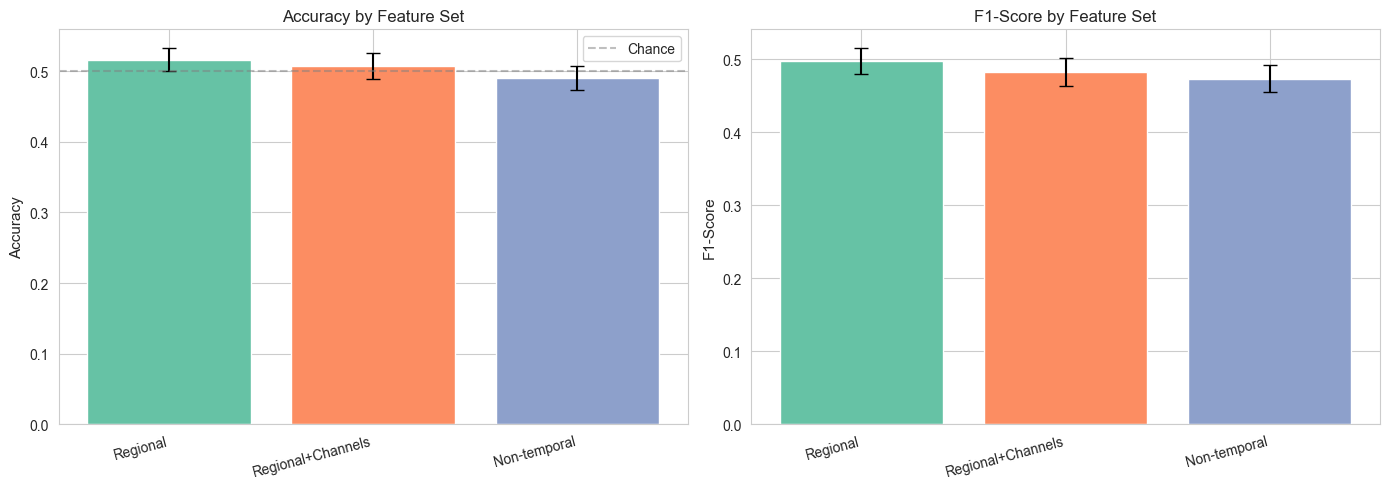


BEST FEATURE SET: Regional
  Accuracy: 0.517 ± 0.016
  F1-Score: 0.498 ± 0.017
  N Features: 16


In [6]:
# Check if we have any results to compare
if len(results) == 0:
    print("\n" + "="*70)
    print("ERROR: No EEG feature sets were loaded!")
    print("="*70)
    print("\nPlease run the extraction scripts first:")
    print("  python scripts/extract_eeg_features.py")
    print("  python scripts/extract_eeg_features_with_channels.py")
    print("  python scripts/extract_eeg_features_non_temporal.py")
    print("\nThen re-run this notebook.")
else:
    # Build comparison dataframe
    comparison_df = pd.DataFrame([
        {
            'Feature Set': r['name'],
            'N Features': r['n_features'],
            'Accuracy': r['accuracy'],
            'Accuracy SEM': r['accuracy_sem'],
            'F1-Score': r['f1'],
            'F1 SEM': r['f1_sem']
        }
        for r in results.values()
    ])

    print(f"\n{'='*70}")
    print(f"COMPARISON OF EEG FEATURE SETS ({TIMEFRAME})")
    print(f"{'='*70}")
    print(comparison_df.to_string(index=False))

    # Visualize comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy comparison
    ax = axes[0]
    x_pos = np.arange(len(comparison_df))
    ax.bar(x_pos, comparison_df['Accuracy'], yerr=comparison_df['Accuracy SEM'],
           color=sns.color_palette('Set2', len(comparison_df)), capsize=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison_df['Feature Set'], rotation=15, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy by Feature Set')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
    ax.legend()

    # F1-Score comparison
    ax = axes[1]
    ax.bar(x_pos, comparison_df['F1-Score'], yerr=comparison_df['F1 SEM'],
           color=sns.color_palette('Set2', len(comparison_df)), capsize=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison_df['Feature Set'], rotation=15, ha='right')
    ax.set_ylabel('F1-Score')
    ax.set_title('F1-Score by Feature Set')

    plt.tight_layout()
    plt.show()

    # Best feature set
    best = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
    print(f"\n{'='*70}")
    print(f"BEST FEATURE SET: {best['Feature Set']}")
    print(f"  Accuracy: {best['Accuracy']:.3f} ± {best['Accuracy SEM']:.3f}")
    print(f"  F1-Score: {best['F1-Score']:.3f} ± {best['F1 SEM']:.3f}")
    print(f"  N Features: {int(best['N Features'])}")
    print(f"{'='*70}")

## 5. Feature Importance Analysis

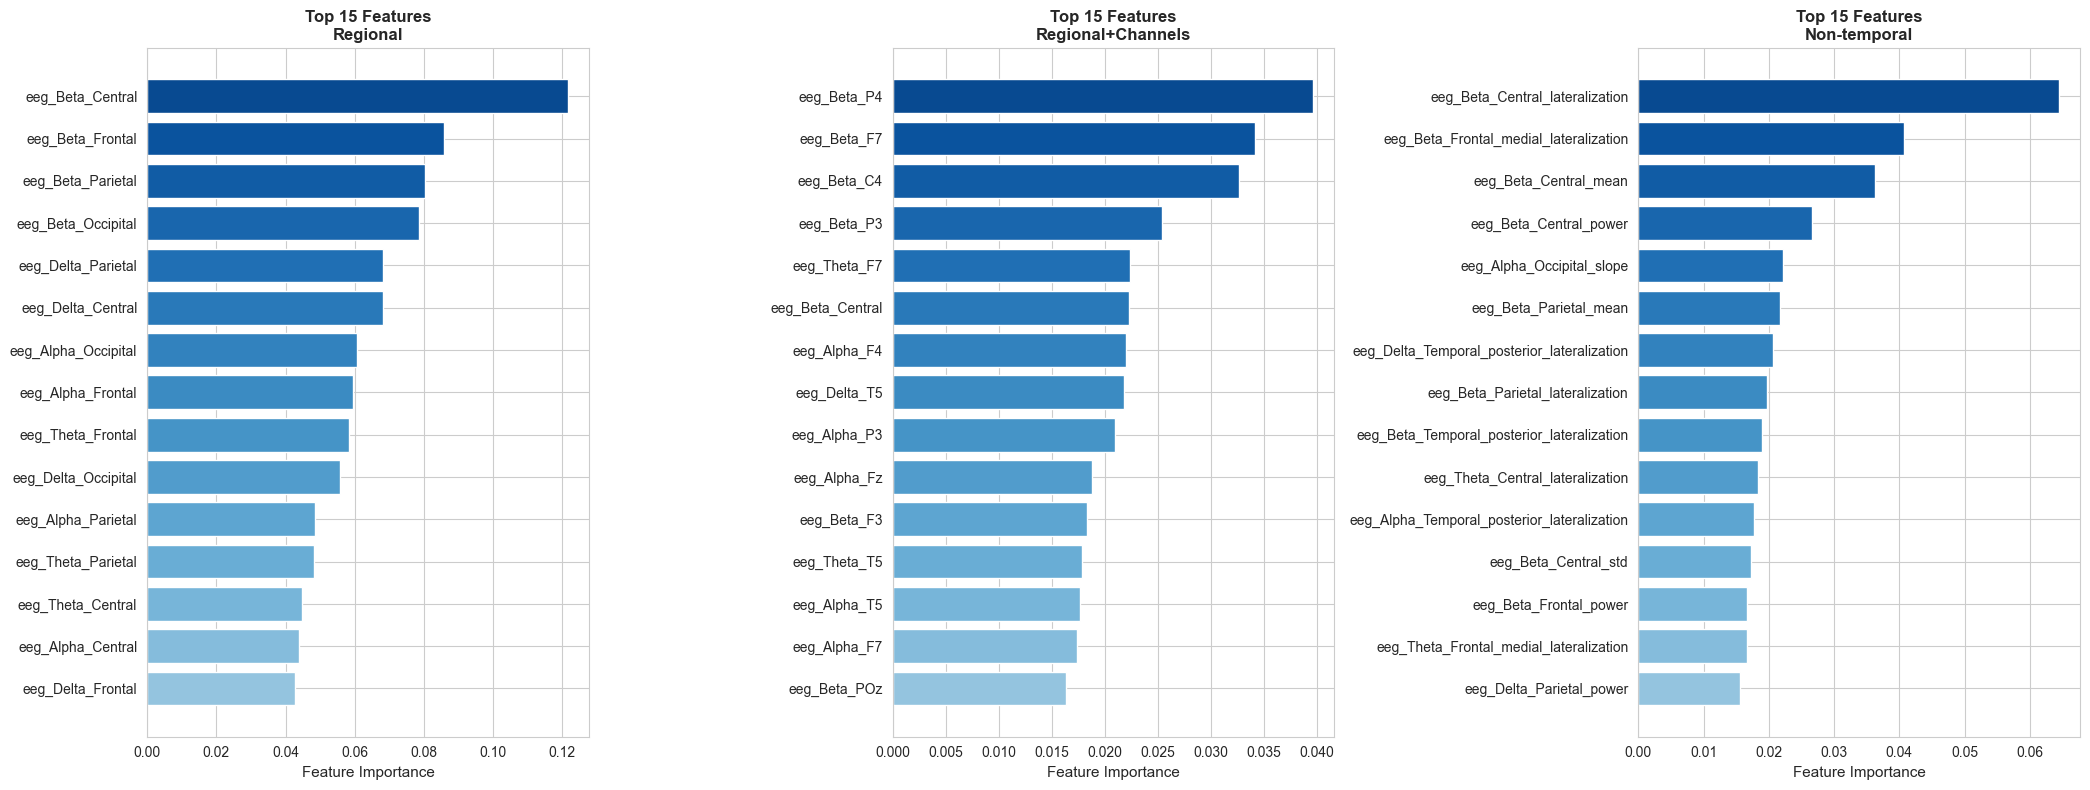

In [7]:
# Plot top features for each set
if len(results) == 0:
    print("No results to plot. Run extraction scripts first.")
else:
    n_top = 15
    n_sets = len(results)

    fig, axes = plt.subplots(1, n_sets, figsize=(7*n_sets, 8))
    if n_sets == 1:
        axes = [axes]

    for idx, (name, result) in enumerate(results.items()):
        ax = axes[idx]
        top_features = result['feature_importances'].head(n_top)
        
        colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_features)))
        ax.barh(range(len(top_features)), top_features['Importance'].values[::-1], color=colors)
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['Feature'].values[::-1])
        ax.set_xlabel('Feature Importance')
        ax.set_title(f'Top {n_top} Features\n{name}', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
## 10. Save Results

# Save all results
if len(results) == 0:
    print("No results to save. Run extraction scripts first.")
else:
    output_dir = f'../../data/results/fusion_models_eeg_{TIMEFRAME}'
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # 1. Single-modality EEG comparison
    save_results(comparison_df, f'{output_dir}/eeg_feature_set_comparison_single_modality.csv')
    
    # 2. Multimodal fusion comparison
    save_results(multimodal_df, f'{output_dir}/eeg_feature_set_comparison_multimodal.csv')
    
    # 3. Modality weights
    save_results(weights_df, f'{output_dir}/eeg_modality_weights_by_feature_set.csv')

    # 4. Feature importances for each set
    for name, result in results.items():
        safe_name = name.replace('+', '_').replace(' ', '_').lower()
        result['feature_importances'].to_csv(
            f'{output_dir}/eeg_feature_importances_{safe_name}.csv',
            index=False
        )
        print(f"✓ Saved {name} feature importances")
    
    # 5. Subject-level accuracies for best multimodal configuration
    for eeg_name, result in fusion_results.items():
        safe_name = eeg_name.replace('+', '_').replace(' ', '_').lower()
        subject_df = pd.DataFrame({
            'subject_id': list(result['results_weighted']['subject_accs'].keys()),
            'accuracy': list(result['results_weighted']['subject_accs'].values())
        })
        save_results(subject_df, f'{output_dir}/multimodal_{safe_name}_subject_accuracies.csv')

    print(f"\n✓ All results saved to: {output_dir}/")

# Extract modality weights for weighted fusion
weights_comparison = []

for eeg_name, result in fusion_results.items():
    weights = result['results_weighted']['weights']
    modality_names = result['modality_names']
    
    for mod_name, weight in zip(modality_names, weights):
        weights_comparison.append({
            'EEG Features': eeg_name,
            'Modality': mod_name,
            'Weight': weight * 100
        })

weights_df = pd.DataFrame(weights_comparison)

print(f"\n{'='*70}")
print(f"MODALITY CONTRIBUTIONS (Weighted Fusion)")
print(f"{'='*70}")
for eeg_name in weights_df['EEG Features'].unique():
    print(f"\n{eeg_name}:")
    subset = weights_df[weights_df['EEG Features'] == eeg_name]
    for _, row in subset.iterrows():
        print(f"  {row['Modality']:12s}: {row['Weight']:5.1f}%")

# Visualize modality weights
fig, ax = plt.subplots(figsize=(12, 6))

weights_pivot = weights_df.pivot(index='Modality', columns='EEG Features', values='Weight')
weights_pivot.plot(kind='bar', ax=ax, width=0.8, color=sns.color_palette('Set2', len(fusion_results)))
ax.set_ylabel('Weight (%)')
ax.set_xlabel('')
ax.set_title('Modality Contributions by EEG Feature Set (Weighted Fusion)', fontweight='bold')
ax.legend(title='EEG Features', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Highlight EEG contribution
print(f"\n{'='*70}")
print(f"EEG MODALITY CONTRIBUTION BY FEATURE SET")
print(f"{'='*70}")
eeg_weights = weights_df[weights_df['Modality'] == 'EEG'].sort_values('Weight', ascending=False)
print(eeg_weights[['EEG Features', 'Weight']].to_string(index=False))
print(f"\nBest EEG contribution: {eeg_weights.iloc[0]['EEG Features']} ({eeg_weights.iloc[0]['Weight']:.1f}%)")

## 7. Multimodal Late Fusion with Each EEG Feature Set

Now evaluate each EEG feature set in **full multimodal late fusion** with physiology, behavior, and gaze.

## 6. Statistical Comparison

In [8]:
# Statistical comparison between feature sets
if len(results) >= 2:
    print(f"\n{'='*70}")
    print(f"STATISTICAL COMPARISONS (Accuracy)")
    print(f"{'='*70}\n")
    
    names = list(results.keys())
    for i in range(len(names)):
        for j in range(i+1, len(names)):
            name1, name2 = names[i], names[j]
            acc1, sem1 = results[name1]['accuracy'], results[name1]['accuracy_sem']
            acc2, sem2 = results[name2]['accuracy'], results[name2]['accuracy_sem']
            
            diff = acc1 - acc2
            diff_sem = np.sqrt(sem1**2 + sem2**2)
            
            print(f"{name1} vs {name2}:")
            print(f"  Difference: {diff:+.3f} ± {diff_sem:.3f}")
            
            if abs(diff) > 2 * diff_sem:
                print(f"  Significant difference (p < 0.05)")
            else:
                print(f"  No significant difference")
            print()


STATISTICAL COMPARISONS (Accuracy)

Regional vs Regional+Channels:
  Difference: +0.009 ± 0.025
  No significant difference

Regional vs Non-temporal:
  Difference: +0.026 ± 0.023
  No significant difference

Regional+Channels vs Non-temporal:
  Difference: +0.017 ± 0.025
  No significant difference



## 7. Save Results

In [9]:
# Save comparison results
if len(results) == 0:
    print("No results to save. Run extraction scripts first.")
else:
    output_dir = f'../../data/results/fusion_models_eeg_{TIMEFRAME}'
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Save comparison table
    comparison_df.to_csv(
        f'{output_dir}/eeg_feature_set_comparison.csv',
        index=False
    )
    print(f"✓ Saved comparison to {output_dir}/eeg_feature_set_comparison.csv")

    # Save feature importances for each set
    for name, result in results.items():
        safe_name = name.replace('+', '_').replace(' ', '_').lower()
        result['feature_importances'].to_csv(
            f'{output_dir}/eeg_feature_importances_{safe_name}.csv',
            index=False
        )
        print(f"✓ Saved {name} feature importances")

    print(f"\nAll results saved to: {output_dir}/")

✓ Saved comparison to ../../data/results/fusion_models_eeg_PRE/eeg_feature_set_comparison.csv
✓ Saved Regional feature importances
✓ Saved Regional+Channels feature importances
✓ Saved Non-temporal feature importances

All results saved to: ../../data/results/fusion_models_eeg_PRE/
